In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('fires_target')

df = pd.DataFrame(df)

In [3]:
df = df[['lat','lon','year','month','temp_month','precip_month','gisacres','fires_target']]
df.head()

,lat,lon,year,month,temp_month,precip_month,gisacres,fires_target
0,39.262110,-108.705537,2005,7,80.060176,0.001951,17.511509,0
1,39.246299,-108.700311,2017,5,61.228730,0.035027,0.707301,0
2,39.261301,-108.714669,2016,7,78.095381,0.015024,0.123598,0
3,40.748563,-107.756655,2015,9,61.494160,0.027260,7.225905,0
4,39.208467,-108.654979,2017,5,61.228730,0.035027,28.773811,0


In [4]:
features = ['lat','lon','year','month','temp_month','precip_month']
target = 'fires_target'

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size = 0.2, random_state = 0)
from sklearn.naive_bayes import GaussianNB


In [6]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train  = sc.fit_transform(X_train)

In [7]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB()
classifier.fit(X_train, y_train)

preds = classifier.predict(sc.transform(X_test))

Text(0.5, 1.0, 'Confusion Matrix for Naive Bayes Classifier')

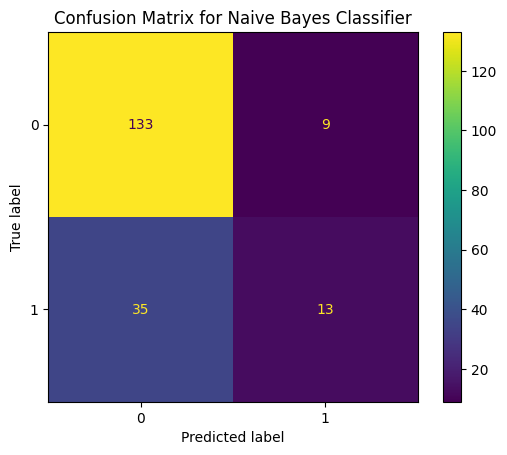

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Naive Bayes Classifier')

In [9]:
accuracy = accuracy_score(y_test, preds)

f1 = f1_score(y_test, preds)

recall = recall_score(y_test, preds)


print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Recall Score: {recall}')

Accuracy: 0.7684210526315789
F1 Score: 0.37142857142857144
Recall Score: 0.2708333333333333
